# Insurance Claim RAG Agent

Parent-child retrieval with HNSW indexing, metadata filtering, memory architecture, and query routing/rewriting.

> **Run each cell sequentially.** If any cell fails, fix the issue and re-run only that cell.

In [2]:
import os
import json
import re
import uuid
import numpy as np
import torch
import torch.nn.functional as F
import chromadb
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModel
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage

# Load environment variables
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# Paths  (edit these if your layout differs)
POLICY_PATH   = "C:/Users/Shaur/Downloads/insurance_policy.md"
CUSTOM_MODEL_PATH = "D:/all-mpnet-base-v2-insurance-final/content/all-mpnet-base-v2-insurance-final"
CHROMA_PATH   = "D:/AIAGENTS/chromadb_rag_agent"
DOCSTORE_PATH = "D:/AIAGENTS/parent_docstore.json"
CITATIONS_PATH = "D:/AIAGENTS/retrieved_chunks.txt"

print("All imports successful ✅")
print(f"Torch version : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GROQ key loaded: {bool(GROQ_API_KEY)}")

d:\AIAGENTS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful ✅
Torch version : 2.9.1+cpu
CUDA available: False
GROQ key loaded: True


## 1. Custom Embedding Model
Loads the fine-tuned model via `transformers` with manual mean-pooling + L2 normalisation.

In [3]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

class CustomEmbeddingsWrapper:
    def __init__(self, model_path_or_name):
        self.tokenizer = AutoTokenizer.from_pretrained(model_path_or_name)
        self.model = AutoModel.from_pretrained(model_path_or_name)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model.eval()

    def encode(self, texts, batch_size=32):
        if isinstance(texts, str):
            texts = [texts]
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            encoded_input = self.tokenizer(
                batch_texts, padding=True, truncation=True,
                return_tensors='pt', max_length=512
            )
            encoded_input = {k: v.to(self.device) for k, v in encoded_input.items()}
            with torch.no_grad():
                model_output = self.model(**encoded_input)
            embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
            embeddings = F.normalize(embeddings, p=2, dim=1)
            all_embeddings.append(embeddings.cpu())
        return torch.cat(all_embeddings, dim=0).numpy().tolist()

print("Loading Custom Embedding Model...")
embedding_model = CustomEmbeddingsWrapper(CUSTOM_MODEL_PATH)
print("Embedding model loaded ✅")

Loading Custom Embedding Model...
Embedding model loaded ✅


## 2. Document Parsing & Parent-Child Chunking
Splits the policy on `##` headings → parent chunks (~2000 words) → child chunks (~500 words).\nMetadata is extracted per section.

In [4]:
def extract_clause_number(section_title):
    match = re.match(r'^\s*([a-zA-Z0-9]+)\.?\s*', section_title)
    return match.group(1) if match else "None"

with open(POLICY_PATH, "r", encoding="utf-8") as f:
    content = f.read()

# Split by ## headers
parts = re.split(r'^(##\s+.*)$', content, flags=re.MULTILINE)

sections = []
first_part = parts[0].strip()
if first_part:
    sections.append({"title": "Preamble", "content": first_part})
for i in range(1, len(parts), 2):
    title = parts[i].replace("##", "").strip()
    body  = parts[i+1].strip() if i+1 < len(parts) else ""
    sections.append({"title": title, "content": body})

print(f"Found {len(sections)} sections:")
for s in sections:
    print(f"  • {s['title'][:80]}  ({len(s['content'])} chars)")

Found 147 sections:
  • b PREAMBLE  (998 chars)
  • c DEFINITIONS  (4303 chars)
  • ICICI LOMBARD COMPLETE HEALTH INSURANCE POLICY WORDING  (5672 chars)
  • Maternity expenses shall  (5417 chars)
  • Specific Definitions (Definitions other than those mentioned under c.i. above)  (5183 chars)
  • d BENEFITS COVERED UNDER THE POLICY  (929 chars)
  • A.  Basic Cover  (82 chars)
  • 1. Inpatient Treatment  (2178 chars)
  • 2. Day Care Procedures/Treatment  (1900 chars)
  • 3. Modern Treatments  (1635 chars)
  • 4. Pre- Hospitalisation Medical Expenses  (614 chars)
  • 5. Post Hospitalization Medical Expenses  (763 chars)
  • 6. In Patient AYUSH Hospitalisation  (523 chars)
  • 7. Reset Benefit  (1350 chars)
  • 8. Domestic Road Ambulance:  (2035 chars)
  • 9. Air Ambulance Cover  (1678 chars)
  • 10. Donor Expenses  (1388 chars)
  • 11. Domiciliary Hospitalization  (985 chars)
  • 12. Home Care Treatment  (1880 chars)
  • 13. Wellness Program  (206 chars)
  • I. Wellness program  (1007 cha

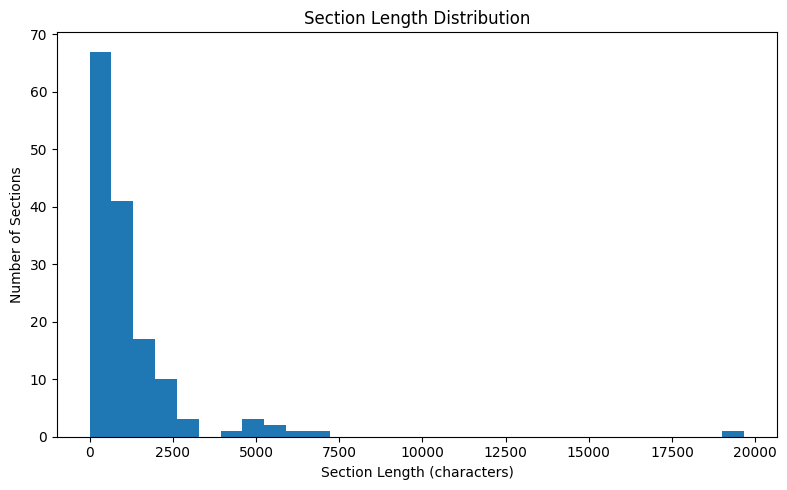

In [15]:
import matplotlib.pyplot as plt

section_lengths = [len(s["content"]) for s in sections]

plt.figure(figsize=(8, 5))

plt.hist(section_lengths, bins=30)

plt.xlabel("Section Length (characters)")
plt.ylabel("Number of Sections")
plt.title("Section Length Distribution")

plt.tight_layout()
plt.show()

## 3. Build HNSW-Indexed Chroma Collection
Creates parent → child mapping, embeds child chunks, and writes them into a Chroma collection with HNSW config.

In [16]:
# Splitters
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=5000, chunk_overlap=500)
child_splitter  = RecursiveCharacterTextSplitter(chunk_size=500,  chunk_overlap=100)

parent_docstore = {}
child_documents, child_metadatas, child_ids = [], [], []

for sec in sections:
    sec_title  = sec["title"]
    sec_content = sec["content"]
    clause = extract_clause_number(sec_title)

    parents = parent_splitter.split_text(sec_content)
    for parent_text in parents:
        parent_id = str(uuid.uuid4())
        parent_docstore[parent_id] = {
            "text": parent_text,
            "section_title": sec_title,
            "clause_number": clause
        }
        children = child_splitter.split_text(parent_text)
        for child_text in children:
            child_id = str(uuid.uuid4())
            child_documents.append(child_text)
            child_ids.append(child_id)
            child_metadatas.append({
                "parent_id": parent_id,
                "policy_name": "insurance_policy.md",
                "section_title": sec_title,
                "subsection_title": sec_title,
                "clause_number": clause
            })

# Save parent docstore
with open(DOCSTORE_PATH, "w", encoding="utf-8") as f:
    json.dump(parent_docstore, f, indent=2)

print(f"Parent chunks : {len(parent_docstore)}")
print(f"Child chunks  : {len(child_documents)}")

Parent chunks : 150
Child chunks  : 556


In [17]:
chroma_client = chromadb.PersistentClient(path=CHROMA_PATH)

policy_collection = chroma_client.create_collection(
    name="policy_collection",
    metadata={
        "hnsw:space": "cosine",
        "hnsw:construction_ef": 100,
        "hnsw:M": 16
    }
)

batch_size = 100
for i in range(0, len(child_documents), batch_size):
    batch_docs  = child_documents[i:i+batch_size]
    batch_metas = child_metadatas[i:i+batch_size]
    batch_ids   = child_ids[i:i+batch_size]
    batch_embs  = embedding_model.encode(batch_docs)
    policy_collection.add(
        embeddings=batch_embs, documents=batch_docs,
        metadatas=batch_metas, ids=batch_ids
    )
    print(f"  Indexed batch {i//batch_size + 1}  ({min(i+batch_size, len(child_documents))}/{len(child_documents)})")

print(f"\nChroma HNSW index built ✅  Total child chunks: {policy_collection.count()}")

  Indexed batch 1  (100/556)
  Indexed batch 2  (200/556)
  Indexed batch 3  (300/556)
  Indexed batch 4  (400/556)
  Indexed batch 5  (500/556)
  Indexed batch 6  (556/556)

Chroma HNSW index built ✅  Total child chunks: 556


## 4. Memory Architecture
- **Short-term**: last 2 conversation turns kept in a Python list (in-context).\n- **Long-term**: older turns stored in a separate Chroma collection.

In [18]:
try:
    chroma_client.delete_collection("memory_collection")
except Exception:
    pass

memory_collection = chroma_client.create_collection(
    name="memory_collection",
    metadata={"hnsw:space": "cosine"}
)
print("Memory collection initialised ✅")

Memory collection initialised ✅


## 5. Insurance Claim Agent Class
Contains query routing (Type A / B), silent query rewriting, retrieval with metadata filtering, citation logging, and LLM response generation.

In [19]:
class InsuranceClaimAgent:
    def __init__(self):
        self.short_term_memory = []  # list of {"role": str, "content": str}
        self.llm = ChatGroq(
            model="llama-3.3-70b-versatile",
            groq_api_key=GROQ_API_KEY,
            temperature=0
        )
        self.policy_collection = chroma_client.get_collection("policy_collection")
        with open(DOCSTORE_PATH, "r", encoding="utf-8") as f:
            self.parent_docstore = json.load(f)

    # ---------- Memory management ----------
    def store_conversation_turn(self, user_query, agent_response):
        if len(self.short_term_memory) >= 4:          # 2 turns × 2 entries
            oldest_user  = self.short_term_memory.pop(0)
            oldest_agent = self.short_term_memory.pop(0)
            mem_text = f"User: {oldest_user['content']}\nAgent: {oldest_agent['content']}"
            mem_emb  = embedding_model.encode([mem_text])[0]
            memory_collection.add(
                embeddings=[mem_emb], documents=[mem_text],
                ids=[str(uuid.uuid4())]
            )
        self.short_term_memory.append({"role": "user",      "content": user_query})
        self.short_term_memory.append({"role": "assistant", "content": agent_response})

    # ---------- Query routing ----------
    def classify_query(self, query):
        if not self.short_term_memory:
            return "Type A"
        sys = (
            "You are a router classifier. Classify the user query into:\n"
            "- 'Type A': Self-contained query, no references to prior turns.\n"
            "- 'Type B': Context-dependent query with pronouns or references.\n"
            "Respond ONLY with 'Type A' or 'Type B'."
        )
        buf = "\n".join([f"{t['role']}: {t['content']}" for t in self.short_term_memory])
        resp = self.llm.invoke([
            SystemMessage(content=sys),
            HumanMessage(content=f"Buffer:\n{buf}\n\nQuery: {query}")
        ])
        cls = resp.content.strip()
        print(f"  ↳ Router → {cls}")
        return cls if cls in ("Type A", "Type B") else "Type A"

    # ---------- Query rewriting (Type B only) ----------
    def rewrite_query(self, query):
        sys = (
            "Rewrite the context-dependent query into a fully self-contained question "
            "using the short-term buffer. Return ONLY the rewritten question."
        )
        buf = "\n".join([f"{t['role']}: {t['content']}" for t in self.short_term_memory])
        resp = self.llm.invoke([
            SystemMessage(content=sys),
            HumanMessage(content=f"Buffer:\n{buf}\n\nAmbiguous Query: {query}")
        ])
        rewritten = resp.content.strip()
        print(f"  ↳ Rewrite: '{query}' → '{rewritten}'")
        return rewritten

    # ---------- Long-term memory retrieval ----------
    def get_long_term_memory(self, query):
        if memory_collection.count() == 0:
            return ""
        qe = embedding_model.encode([query])[0]
        res = memory_collection.query(
            query_embeddings=[qe],
            n_results=min(2, memory_collection.count())
        )
        if res and res["documents"] and res["documents"][0]:
            return "\n\n".join(res["documents"][0])
        return ""

    # ---------- Policy retrieval with metadata filter ----------
    def retrieve_policy_context(self, query, metadata_filter=None):
        qe = embedding_model.encode([query])[0]
        results = self.policy_collection.query(
            query_embeddings=[qe], n_results=3,
            where=metadata_filter
        )
        parents, citations = [], []
        if results and results["ids"] and results["ids"][0]:
            for idx in range(len(results["ids"][0])):
                meta = results["metadatas"][0][idx]
                doc  = results["documents"][0][idx]
                dist = results["distances"][0][idx] if "distances" in results else 0.0
                score = 1.0 - dist

                parent_data = self.parent_docstore.get(meta["parent_id"], {})
                parent_text = parent_data.get("text", "")

                parents.append({"text": parent_text, "metadata": meta})
                citations.append(
                    f"--- RETRIEVED CHUNK {idx+1} (Score: {score:.4f}) ---\n"
                    f"Section : {meta['section_title']}\n"
                    f"Clause  : {meta['clause_number']}\n"
                    f"Policy  : {meta['policy_name']}\n\n"
                    f"CHILD SNIPPET:\n{doc}\n\n"
                    f"PARENT CONTENT:\n{parent_text}\n"
                    f"{'='*60}\n\n"
                )
        with open(CITATIONS_PATH, "w", encoding="utf-8") as f:
            f.writelines(citations)
        return parents

    # ---------- Full pipeline ----------
    def generate_response(self, user_query, metadata_filter=None):
        print(f"\n{'─'*60}")
        print(f"Query: {user_query}")
        original = user_query

        q_type = self.classify_query(user_query)
        if q_type == "Type B":
            user_query = self.rewrite_query(user_query)

        policy_results = self.retrieve_policy_context(user_query, metadata_filter)
        lt_mem = self.get_long_term_memory(user_query)

        ctx = "\n\n".join([
            f"Section: {r['metadata']['section_title']} | Clause: {r['metadata']['clause_number']}\n{r['text']}"
            for r in policy_results
        ])

        sys_prompt = (
            "You are an intelligent Insurance Claim AI Agent. "
            "Answer ONLY from the retrieved policy chunks.\n"
            "Cite specific sections and clause numbers.\n"
            "Distinguish covered vs excluded. Flag ambiguous cases for human escalation.\n"
            "Tone: concise, professional, empathetic."
        )
        user_prompt = f"Retrieved Policy Context:\n{ctx}\n\n"
        if lt_mem:
            user_prompt += f"Long-Term Memory:\n{lt_mem}\n\n"
        if self.short_term_memory:
            buf = "\n".join([f"{t['role']}: {t['content']}" for t in self.short_term_memory])
            user_prompt += f"Short-Term Buffer:\n{buf}\n\n"
        user_prompt += f"Question: {user_query}"

        resp = self.llm.invoke([
            SystemMessage(content=sys_prompt),
            HumanMessage(content=user_prompt)
        ])
        self.store_conversation_turn(original, resp.content)
        return resp.content

print("InsuranceClaimAgent class defined ✅")

InsuranceClaimAgent class defined ✅


## 6. Test Queries
### Test 1 — Type A (Self-Contained)

In [20]:
agent = InsuranceClaimAgent()

answer = agent.generate_response("What does the policy state about ICU charges?")
print("\n📄 ANSWER:\n")
print(answer)
print(f"\n📎 Citations saved to: {CITATIONS_PATH}")


────────────────────────────────────────────────────────────
Query: What does the policy state about ICU charges?

📄 ANSWER:

According to Section: 1. Inpatient Treatment | Clause: 1, the policy states that it will cover "Intensive Care Unit Charges" ( Clause 1, ii). Additionally, it is mentioned that "Proportionate deductions are not applicable for ICU charges" (Section: 1. Inpatient Treatment | Clause: 1, i, b), meaning that the insured person will not have to bear a proportionate deduction for ICU charges if they are admitted to a higher room category than specified in the policy schedule. This indicates that ICU charges are a **covered** expense under the policy.

📎 Citations saved to: D:/AIAGENTS/retrieved_chunks.txt


### Test 2 — Type B (Context-Dependent)
This follow-up should be classified as Type B and silently rewritten.

In [21]:
answer = agent.generate_response("What about Day Care Procedures? Is there a limit on them too?")
print("\n📄 ANSWER:\n")
print(answer)


────────────────────────────────────────────────────────────
Query: What about Day Care Procedures? Is there a limit on them too?
  ↳ Router → Type B
  ↳ Rewrite: 'What about Day Care Procedures? Is there a limit on them too?' → 'What does the policy state about coverage and potential limits for Day Care Procedures?'

📄 ANSWER:

According to Section: 2. Day Care Procedures/Treatment | Clause: 2, the policy states that it will cover Medical Expenses incurred in respect of Day Care Treatment of the Insured Person during the Policy Period up to the Annual Sum Insured. 

The policy specifies that Day Care treatment requires hospitalization as an inpatient for less than 24 hours in a Hospital (Section: 2, i). It also covers Medical Expenses for procedures including intravenous chemotherapy, radiotherapy, hemodialysis, or any other therapeutic procedure requiring specialized observation or medical care after completion (Section: 2, ii).

However, it excludes Out Patient Treatment or diagnos

### Test 3 — Metadata-Filtered Retrieval
Restricts search to the **Definitions** section only.

In [10]:
answer = agent.generate_response(
    "What are standard definitions of Grace Period?",
    metadata_filter={"section_title": "c DEFINITIONS"}
)
print("\n📄 ANSWER:\n")
print(answer)


────────────────────────────────────────────────────────────
Query: What are standard definitions of Grace Period?
  ↳ Router → Type A

📄 ANSWER:

According to the retrieved policy context, there is no explicit definition of "Grace Period" in Section: c DEFINITIONS | Clause: c. The policy provides definitions for terms such as "Accident", "Any one illness", "Ayush Hospital", "Ayush Day Care Centre", "Cashless Facility", "Condition Precedent", "Congenital Anomaly", "Co-Payment", "Cumulative Bonus", and "Day Care Centre", but it does not define "Grace Period".

As the definition of "Grace Period" is not provided in the retrieved policy context, I would flag this as an ambiguous case and recommend escalation to a human representative for further clarification.


## 7. Inspect Retrieved Chunks
Print the raw citations file so you can verify grounding.

In [ ]:
with open(CITATIONS_PATH, "r", encoding="utf-8") as f:
    print(f.read())

## 8. Interactive Chat Loop *(optional)*
Run this cell to chat with the agent interactively. Type `quit` to stop.

In [ ]:
# Uncomment below to start an interactive session
# agent = InsuranceClaimAgent()
# while True:
#     q = input("You: ")
#     if q.strip().lower() in ("quit", "exit"):
#         break
#     ans = agent.generate_response(q)
#     print(f"\nAgent:\n{ans}\n")